In [ ]:
!pip install -q pandas==2.2.3 scanpy


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 95.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 67.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.1/176.1 kB 12.0 MB/s eta 0:00:00


In [ ]:
!pip install -q scanpy leidenalg igraph pydeseq2 gseapy pandas==2.2.3


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.7/689.7 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.1/176.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 376.9/376.9 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.1/225.1 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 66.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.6/87.6 kB 6.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt

from scipy.io import mmread
from scipy.sparse import vstack

print("Setup working")

Setup working


In [ ]:
!wget -q \
"https://ftp.ncbi.nlm.nih.gov/geo/series/GSE221nnn/GSE221042/suppl/GSE221042_data.mtx.gz" \
-O expression.mtx.gz

!wget -q \
"https://ftp.ncbi.nlm.nih.gov/geo/series/GSE221nnn/GSE221042/suppl/GSE221042_genes.csv.gz" \
-O genes.csv.gz

!wget -q \
"https://ftp.ncbi.nlm.nih.gov/geo/series/GSE221nnn/GSE221042/suppl/GSE221042_sample_annotations.csv.gz" \
-O metadata.csv.gz

print("Downloaded")

Downloaded


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
print("Pandas is working")
print("Scanpy is working")

Pandas is working
Scanpy is working


In [ ]:
import pandas as pd

url = "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE221nnn/GSE221042/suppl/GSE221042_sample_annotations.csv.gz"

metadata = pd.read_csv(url)

print(metadata.shape)
metadata.head()

(70973, 5)


,Unnamed: 0,sample_labels,condition_labels,n_genes_by_counts,total_counts
0,AAACCCACATACGCAT-1,AMD0233,wAMD,1607,10961
1,AAACGAATCCGTGGTG-1,AMD0233,wAMD,1305,6945
2,AAACGCTAGGGCCAAT-1,AMD0233,wAMD,2384,16809
3,AAACGCTCATGGCTAT-1,AMD0233,wAMD,1062,1528
4,AAAGAACAGCATTGAA-1,AMD0233,wAMD,1833,3397


In [ ]:
print(metadata["condition_labels"].value_counts())

condition_labels
wAMD       29424
dAMD       24151
Healthy    17398
Name: count, dtype: int64


In [ ]:
print(metadata["sample_labels"].value_counts())

sample_labels
A181974MR      7888
AMD201257      7476
AMD201232      6696
A192617MR      6318
AMD1547        5349
AMD19-1891     5129
G1850          4816
AMD192161MR    4621
HC1969         4427
HC2016         4086
AMD1098        3466
A19-0065MR     3362
HC1941W        3019
AMD0233        1535
HC2229         1321
HC2003         1183
AMD1435         281
Name: count, dtype: int64


In [ ]:
!wget -q \
"https://ftp.ncbi.nlm.nih.gov/geo/series/GSE221nnn/GSE221042/suppl/GSE221042_genes.csv.gz" \
-O genes.csv.gz

genes = pd.read_csv("genes.csv.gz")

print(genes.shape)
genes.head(10)

(28260, 2)


,0,A1BG (ENSG00000121410)
0,1,A1BG-AS1 (ENSG00000268895)
1,2,A1CF (ENSG00000148584)
2,3,A2M (ENSG00000175899)
3,4,A2M-AS1 (ENSG00000245105)
4,5,A2ML1 (ENSG00000166535)
5,6,A2ML1-AS1 (ENSG00000256661)
6,7,A3GALT2 (ENSG00000184389)
7,8,A4GALT (ENSG00000128274)
8,9,A4GNT (ENSG00000118017)
9,10,AAAS (ENSG00000094914)


In [ ]:
!wget --progress=bar:force \
"https://ftp.ncbi.nlm.nih.gov/geo/series/GSE221nnn/GSE221042/suppl/GSE221042_data.mtx.gz" \
-O expression.mtx.gz

--2026-09-11 09:27:17--  https://ftp.ncbi.nlm.nih.gov/geo/series/GSE221nnn/GSE221042/suppl/GSE221042_data.mtx.gz
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.11, 130.14.250.12, 2607:f220:41e:250::12, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.11|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 443032650 (423M) [application/x-gzip]
Saving to: ‘expression.mtx.gz’

expression.mtx.gz   100%[===================>] 422.51M  15.0MB/s    in 13s     

2026-09-11 09:27:30 (31.5 MB/s) - ‘expression.mtx.gz’ saved [443032650/443032650]



In [ ]:
!wget -q \
"https://ftp.ncbi.nlm.nih.gov/geo/series/GSE221nnn/GSE221042/suppl/GSE221042_genes.csv.gz" \
-O genes.csv.gz

genes = pd.read_csv("genes.csv.gz")

print(genes.shape)
genes.head(10)

(28260, 2)


,0,A1BG (ENSG00000121410)
0,1,A1BG-AS1 (ENSG00000268895)
1,2,A1CF (ENSG00000148584)
2,3,A2M (ENSG00000175899)
3,4,A2M-AS1 (ENSG00000245105)
4,5,A2ML1 (ENSG00000166535)
5,6,A2ML1-AS1 (ENSG00000256661)
6,7,A3GALT2 (ENSG00000184389)
7,8,A4GALT (ENSG00000128274)
8,9,A4GNT (ENSG00000118017)
9,10,AAAS (ENSG00000094914)


In [ ]:
from scipy.io import mmread

X = mmread("expression.mtx.gz").tocsr()

print("Expression matrix shape:", X.shape)
print("Metadata:", metadata.shape)
print("Genes:", genes.shape)

Expression matrix shape: (70973, 28261)
Metadata: (70973, 5)
Genes: (28260, 2)


In [ ]:
print("First 5 gene rows:")
print(genes.head())

print("\nLast 5 gene rows:")
print(genes.tail())

print("\nMatrix columns:", X.shape[1])
print("Gene rows:", len(genes))

First 5 gene rows:
   0      A1BG (ENSG00000121410)
0  1  A1BG-AS1 (ENSG00000268895)
1  2      A1CF (ENSG00000148584)
2  3       A2M (ENSG00000175899)
3  4   A2M-AS1 (ENSG00000245105)
4  5     A2ML1 (ENSG00000166535)

Last 5 gene rows:
           0    A1BG (ENSG00000121410)
28255  28256    ZXDC (ENSG00000070476)
28256  28257  ZYG11A (ENSG00000203995)
28257  28258  ZYG11B (ENSG00000162378)
28258  28259     ZYX (ENSG00000159840)
28259  28260   ZZEF1 (ENSG00000074755)

Matrix columns: 28261
Gene rows: 28260


In [ ]:
print(genes.columns.tolist())

['0', 'A1BG (ENSG00000121410)']


In [ ]:
genes = pd.read_csv("genes.csv.gz", header=None)

print("Genes:", genes.shape)
genes.head()

Genes: (28261, 2)


,0,1
0,0,A1BG (ENSG00000121410)
1,1,A1BG-AS1 (ENSG00000268895)
2,2,A1CF (ENSG00000148584)
3,3,A2M (ENSG00000175899)
4,4,A2M-AS1 (ENSG00000245105)


In [ ]:
import scanpy as sc

adata = sc.AnnData(X=X)

# Add gene names
adata.var_names = genes[1].values

# Add the information about each nucleus
adata.obs = metadata.copy()

print(adata)

AnnData object with n_obs × n_vars = 70973 × 28261
    obs: 'Unnamed: 0', 'sample_labels', 'condition_labels', 'n_genes_by_counts', 'total_counts'


/usr/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [ ]:
print(adata.obs.columns)

Index(['Unnamed: 0', 'sample_labels', 'condition_labels', 'n_genes_by_counts',
       'total_counts'],
      dtype='object')


In [ ]:
muller_markers = ["RLBP1", "GLUL", "SLC1A3", "RGR"]

for gene in muller_markers:
    print(gene, gene in adata.var_names)

RLBP1 False
GLUL False
SLC1A3 False
RGR False


In [ ]:
adata.var_names = genes[1].str.split(" ").str[0].values

print(adata.var_names[:10])

Index(['A1BG', 'A1BG-AS1', 'A1CF', 'A2M', 'A2M-AS1', 'A2ML1', 'A2ML1-AS1',
       'A3GALT2', 'A4GALT', 'A4GNT'],
      dtype='object')


In [ ]:
muller_markers = ["RLBP1", "GLUL", "SLC1A3", "RGR"]

for gene in muller_markers:
    print(gene, gene in adata.var_names)

RLBP1 True
GLUL True
SLC1A3 True
RGR True


In [ ]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

sc.pl.violin(
    adata,
    ["RLBP1", "GLUL", "SLC1A3", "RGR"],
    groupby="condition_labels",
    rotation=45
)

ValueError: adata.var_names contains duplicated items
Please rename these var names first for example using `adata.var_names_make_unique()`

In [ ]:
adata.var_names_make_unique()

print("Gene names unique:", adata.var_names.is_unique)

Gene names unique: True


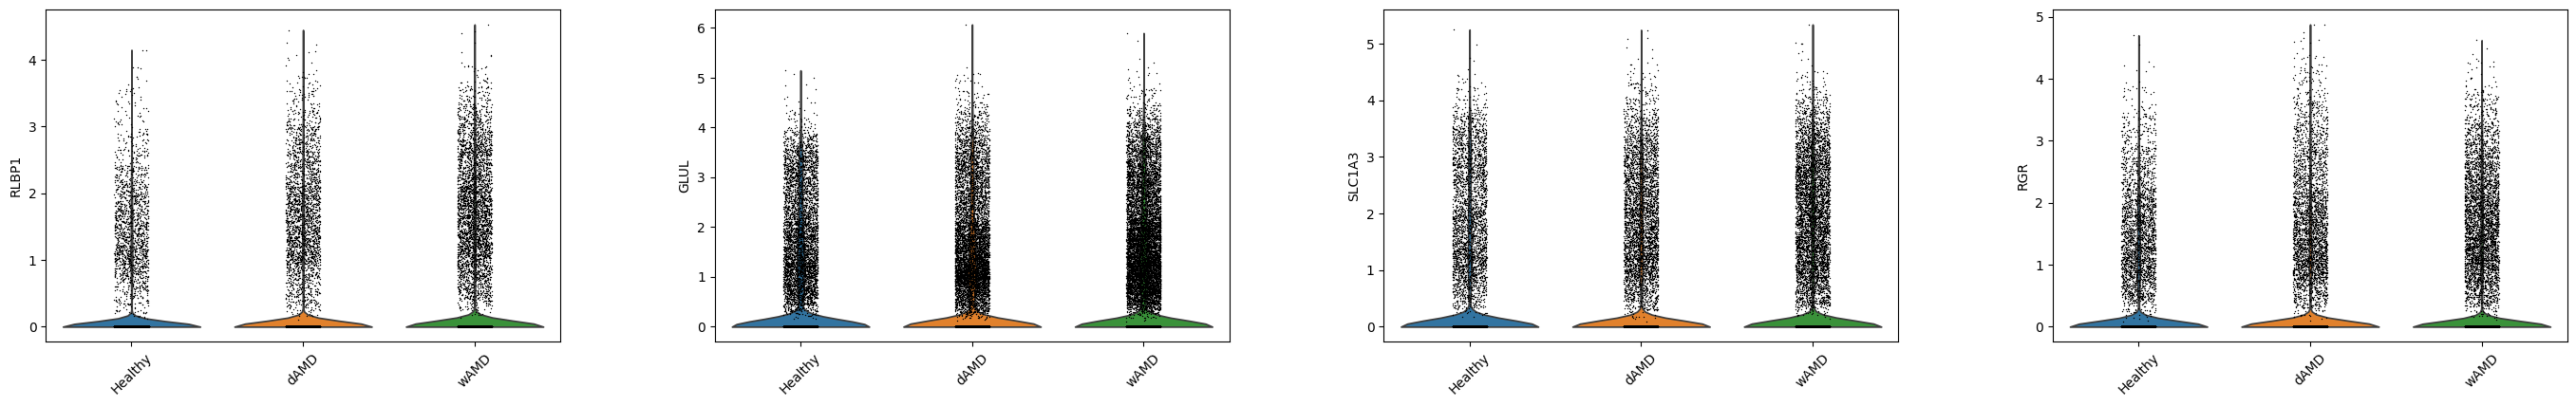

In [ ]:
sc.pl.violin(
    adata,
    ["RLBP1", "GLUL", "SLC1A3", "RGR"],
    groupby="condition_labels",
    rotation=45
)

In [ ]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
sc.tl.pca(adata, use_highly_variable=True)
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30)
sc.tl.umap(adata)

/tmp/ipykernel_3963/2045858440.py:2: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  sc.tl.pca(adata, use_highly_variable=True)


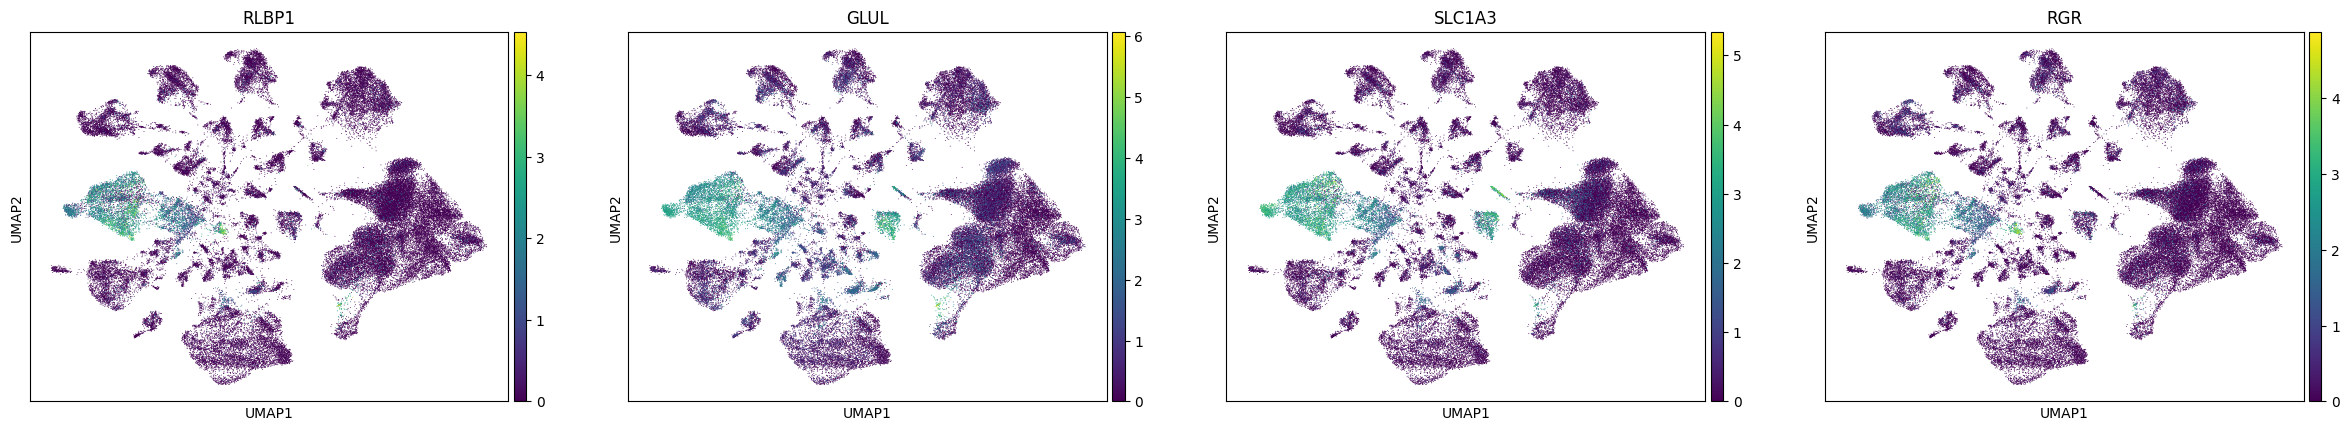

In [ ]:
 sc.pl.umap(
    adata,
    color=["RLBP1", "GLUL", "SLC1A3", "RGR"]
)

In [ ]:
!pip install -q leidenalg igraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 61.8 MB/s eta 0:00:00


/tmp/ipykernel_3963/1786576431.py:1: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=0.5)


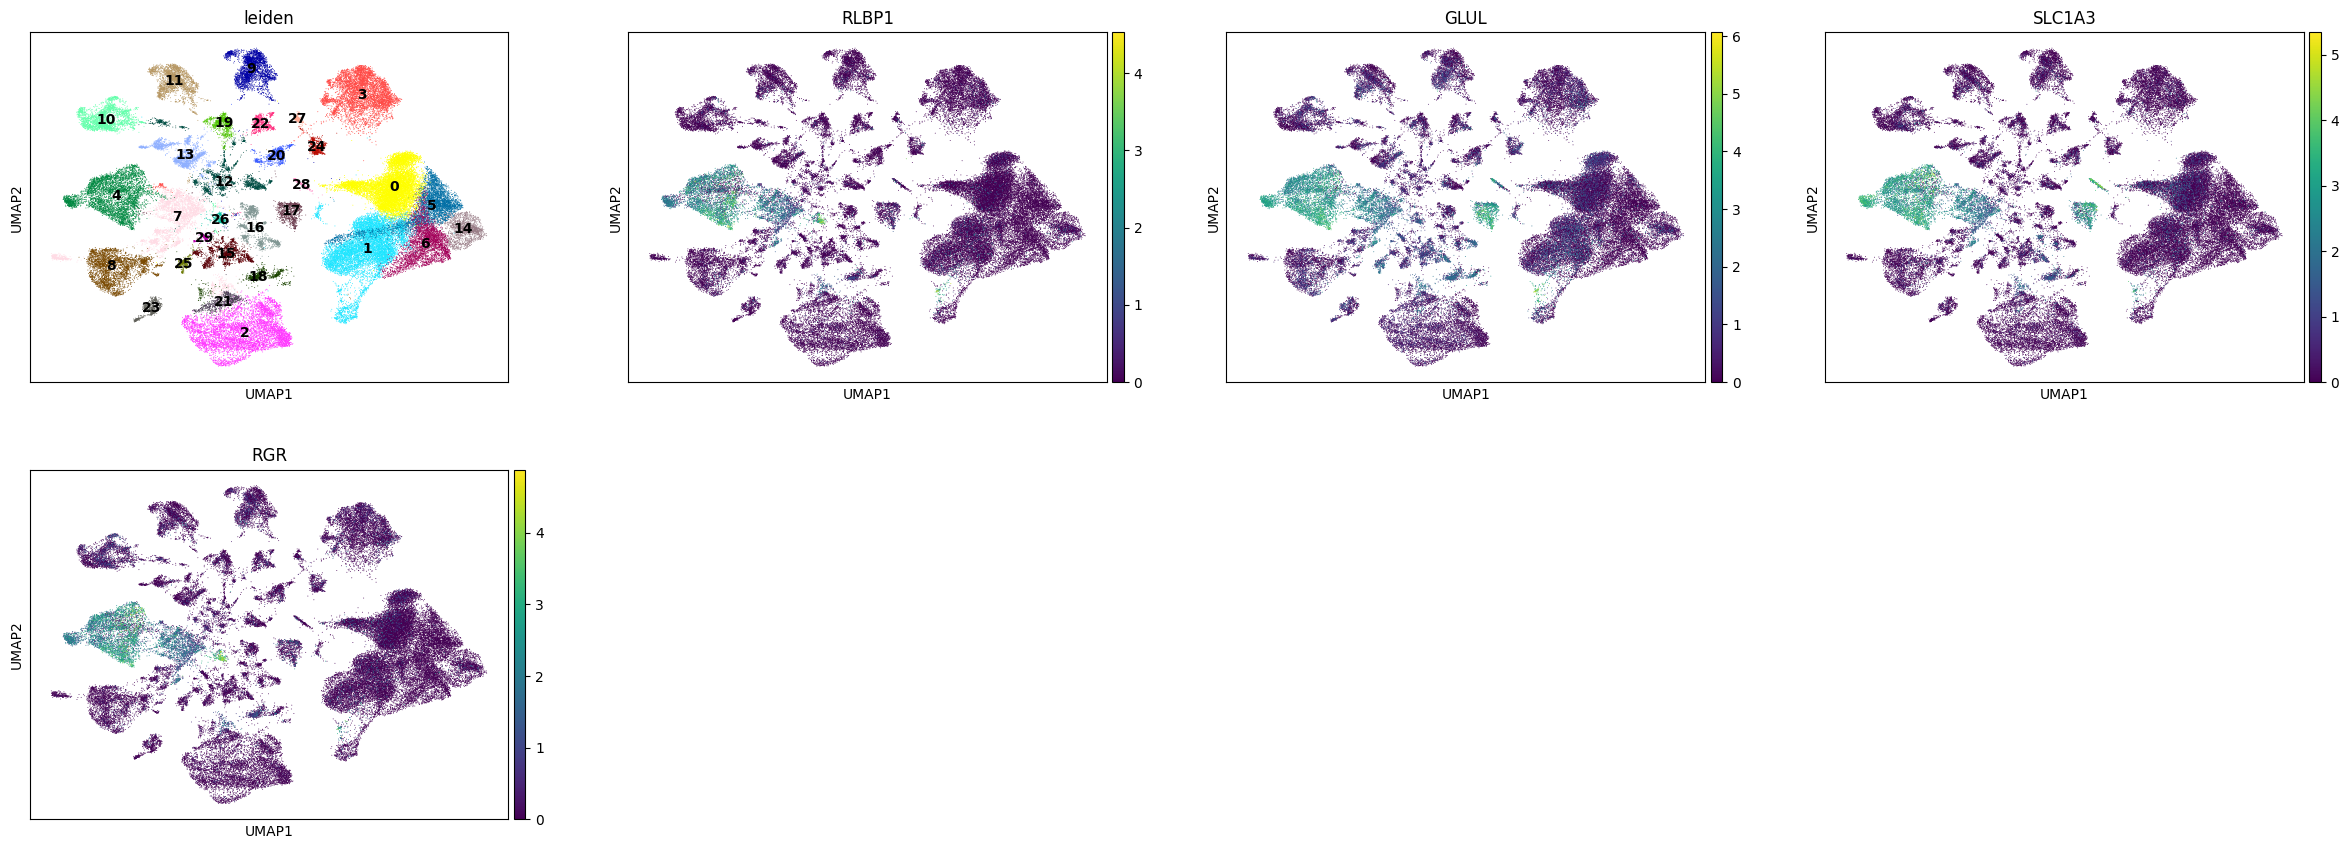

In [ ]:
sc.tl.leiden(adata, resolution=0.5)

sc.pl.umap(
    adata,
    color=["leiden", "RLBP1", "GLUL", "SLC1A3", "RGR"],
    legend_loc="on data"
)

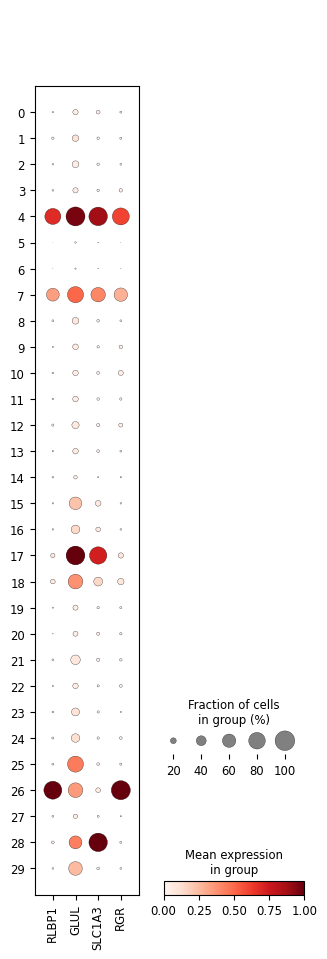

In [ ]:
markers = ["RLBP1", "GLUL", "SLC1A3", "RGR"]

sc.pl.dotplot(
    adata,
    markers,
    groupby="leiden",
    standard_scale="var"
)

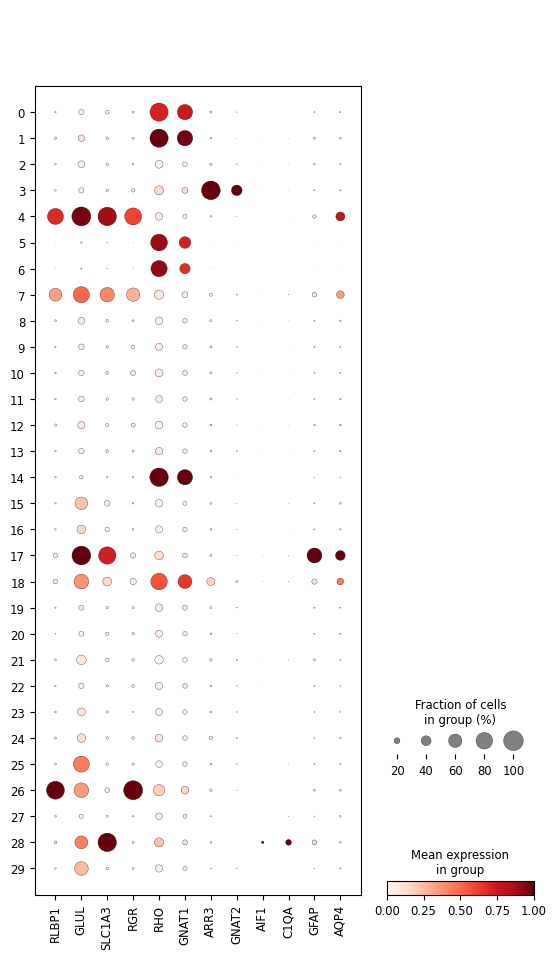

In [ ]:
retina_markers = [
    # Muller glia
    "RLBP1", "GLUL", "SLC1A3", "RGR",

    # Rods
    "RHO", "GNAT1",

    # Cones
    "ARR3", "GNAT2",

    # Microglia
    "AIF1", "C1QA",

    # Astrocytes
    "GFAP", "AQP4"
]

sc.pl.dotplot(
    adata,
    retina_markers,
    groupby="leiden",
    standard_scale="var"
)

In [ ]:
muller_markers = ["RLBP1", "GLUL", "SLC1A3", "RGR"]

sc.tl.score_genes(
    adata,
    gene_list=muller_markers,
    score_name="muller_score"
)

cluster_scores = (
    adata.obs
    .groupby("leiden", observed=True)["muller_score"]
    .mean()
    .sort_values(ascending=False)
)

print(cluster_scores.head(10))

leiden
4     1.950962
26    1.347848
17    1.099089
28    0.866137
7     0.697562
18    0.132876
25    0.035520
6    -0.074605
1    -0.103385
5    -0.108085
Name: muller_score, dtype: float64


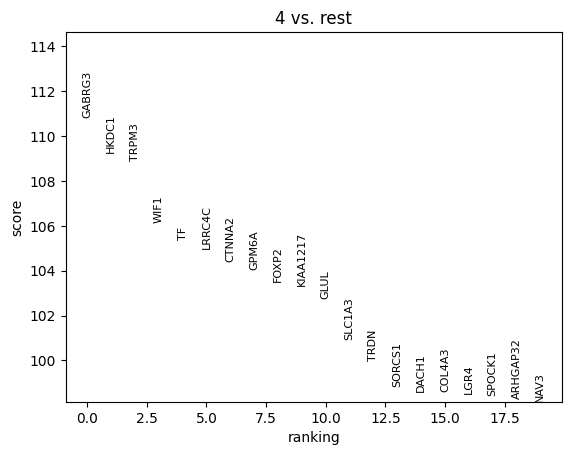

In [ ]:
sc.tl.rank_genes_groups(
    adata,
    groupby="leiden",
    groups=["4"],
    reference="rest",
    method="wilcoxon"
)

sc.pl.rank_genes_groups(
    adata,
    groups=["4"],
    n_genes=20
)

In [ ]:
muller = adata[adata.obs["leiden"] == "4"].copy()

print("Number of Muller glia:", muller.n_obs)
print()
print(muller.obs["condition_labels"].value_counts())

Number of Muller glia: 4594

condition_labels
wAMD       1879
dAMD       1480
Healthy    1235
Name: count, dtype: int64


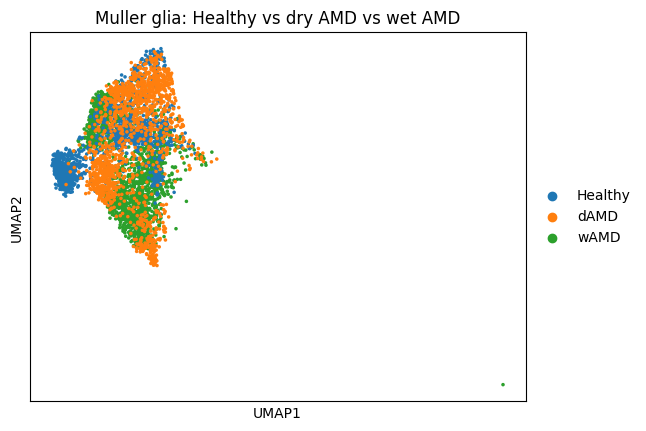

In [ ]:
sc.pl.umap(
    muller,
    color="condition_labels",
    title="Muller glia: Healthy vs dry AMD vs wet AMD"
)

In [ ]:
oxphos_genes = [
    "NDUFA1", "NDUFB1", "NDUFS1",
    "SDHA", "SDHB",
    "UQCRC1", "UQCRC2",
    "COX4I1", "COX5A",
    "ATP5F1A", "ATP5F1B"
]

glycolysis_genes = [
    "HK1", "HK2",
    "PFKM", "PFKP",
    "ALDOA",
    "GAPDH",
    "PGK1",
    "ENO1",
    "PKM",
    "LDHA"
]

oxidative_stress_genes = [
    "SOD1", "SOD2",
    "CAT",
    "GPX1", "GPX4",
    "PRDX1", "PRDX2",
    "NFE2L2",
    "HMOX1"
]

In [ ]:
for name, gene_list in {
    "OXPHOS": oxphos_genes,
    "Glycolysis": glycolysis_genes,
    "Oxidative stress": oxidative_stress_genes
}.items():

    present = [g for g in gene_list if g in muller.var_names]
    print(name, len(present), "/", len(gene_list), "genes present")

OXPHOS 11 / 11 genes present
Glycolysis 10 / 10 genes present
Oxidative stress 7 / 9 genes present


In [ ]:
for name, gene_list in {
    "OXPHOS": oxphos_genes,
    "Glycolysis": glycolysis_genes,
    "Oxidative stress": oxidative_stress_genes
}.items():

    present = [g for g in gene_list if g in muller.var_names]
    print(name, len(present), "/", len(gene_list), "genes present")

OXPHOS 11 / 11 genes present
Glycolysis 10 / 10 genes present
Oxidative stress 7 / 9 genes present


In [ ]:
sc.tl.score_genes(
    muller,
    [g for g in oxphos_genes if g in muller.var_names],
    score_name="OXPHOS_score"
)

sc.tl.score_genes(
    muller,
    [g for g in glycolysis_genes if g in muller.var_names],
    score_name="Glycolysis_score"
)

sc.tl.score_genes(
    muller,
    [g for g in oxidative_stress_genes if g in muller.var_names],
    score_name="OxStress_score"
)

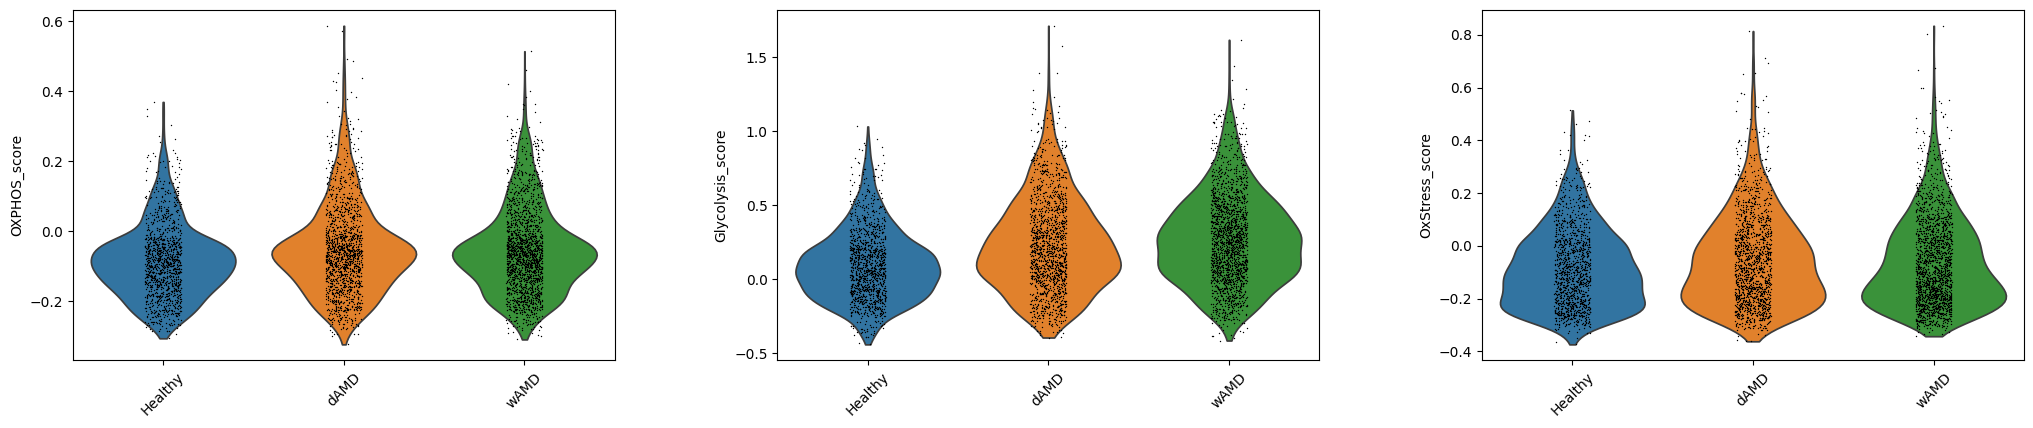

In [ ]:
sc.pl.violin(
    muller,
    ["OXPHOS_score", "Glycolysis_score", "OxStress_score"],
    groupby="condition_labels",
    rotation=45
)

In [ ]:
sample_scores = (
    muller.obs
    .groupby(["sample_labels", "condition_labels"], observed=True)
    [["OXPHOS_score", "Glycolysis_score", "OxStress_score"]]
    .mean()
    .reset_index()
)

print(sample_scores)

   sample_labels condition_labels  OXPHOS_score  Glycolysis_score  \
0     A19-0065MR          Healthy     -0.075056          0.216583   
1      A181974MR             dAMD      0.000047          0.584790   
2      A192617MR             dAMD     -0.060006          0.151935   
3     AMD19-1891             dAMD     -0.053965          0.333043   
4        AMD0233             wAMD     -0.091585          0.032962   
5        AMD1098             wAMD     -0.023442          0.214352   
6        AMD1435             wAMD     -0.060029          0.424279   
7        AMD1547             wAMD     -0.086389          0.056353   
8    AMD192161MR             wAMD     -0.042512          0.456050   
9      AMD201232             wAMD     -0.047114          0.453162   
10     AMD201257             wAMD     -0.036553          0.300152   
11         G1850             dAMD     -0.061849          0.036299   
12       HC1941W          Healthy     -0.062474          0.332332   
13        HC1969          Healthy 

/tmp/ipykernel_3963/4230633682.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=["Healthy", "dAMD", "wAMD"])


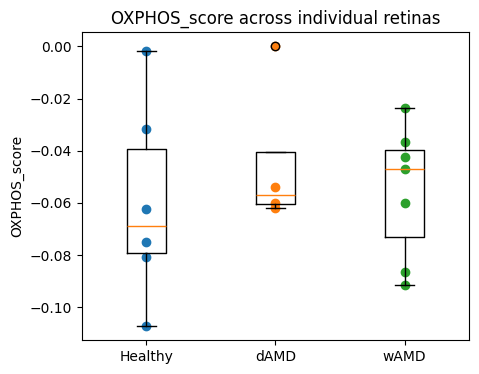

/tmp/ipykernel_3963/4230633682.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=["Healthy", "dAMD", "wAMD"])


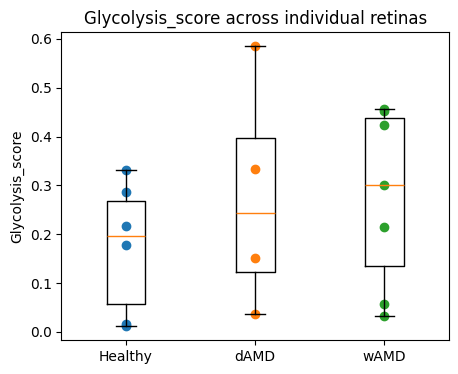

/tmp/ipykernel_3963/4230633682.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=["Healthy", "dAMD", "wAMD"])


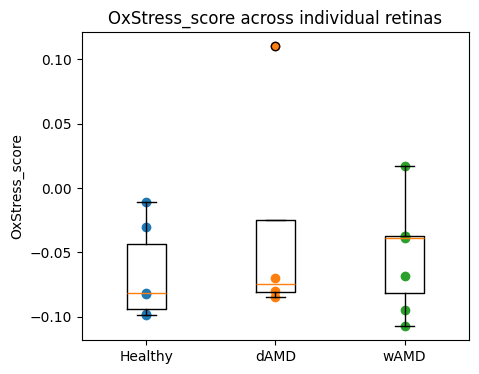

In [ ]:
import matplotlib.pyplot as plt

scores = ["OXPHOS_score", "Glycolysis_score", "OxStress_score"]

for score in scores:
    groups = [
        sample_scores.loc[
            sample_scores["condition_labels"] == condition, score
        ].values
        for condition in ["Healthy", "dAMD", "wAMD"]
    ]

    plt.figure(figsize=(5,4))
    plt.boxplot(groups, labels=["Healthy", "dAMD", "wAMD"])

    for i, values in enumerate(groups, start=1):
        plt.scatter([i] * len(values), values)

    plt.ylabel(score)
    plt.title(score + " across individual retinas")
    plt.show()

In [ ]:
metadata = pd.read_csv("metadata.csv.gz")
genes = pd.read_csv("genes.csv.gz", header=None)
X_raw = mmread("expression.mtx.gz").tocsr()

print("Raw matrix:", X_raw.shape)
print("Metadata:", metadata.shape)
print("Genes:", genes.shape)

Raw matrix: (70973, 28261)
Metadata: (70973, 5)
Genes: (28261, 2)


In [ ]:
adata = sc.AnnData(X=X_raw.copy())

adata.var_names = genes[1].str.split(" ").str[0].values
adata.var_names_make_unique()

adata.obs = metadata.copy()

print(adata)

AnnData object with n_obs × n_vars = 70973 × 28261
    obs: 'Unnamed: 0', 'sample_labels', 'condition_labels', 'n_genes_by_counts', 'total_counts'


/usr/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [ ]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

sc.pp.highly_variable_genes(adata, n_top_genes=2000)
sc.tl.pca(adata, mask_var="highly_variable")

sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30)
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution=0.5)

/tmp/ipykernel_7807/56631382.py:9: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=0.5)


In [ ]:
muller_markers = ["RLBP1", "GLUL", "SLC1A3", "RGR"]

sc.tl.score_genes(
    adata,
    muller_markers,
    score_name="muller_score"
)

cluster_scores = (
    adata.obs
    .groupby("leiden", observed=True)["muller_score"]
    .mean()
    .sort_values(ascending=False)
)

print(cluster_scores.head(10))

best_cluster = cluster_scores.index[0]

print("\nCandidate Müller cluster:", best_cluster)

leiden
4     1.950962
26    1.347848
17    1.099089
28    0.866137
7     0.697562
18    0.132876
25    0.035520
6    -0.074605
1    -0.103385
5    -0.108085
Name: muller_score, dtype: float64

Candidate Müller cluster: 4


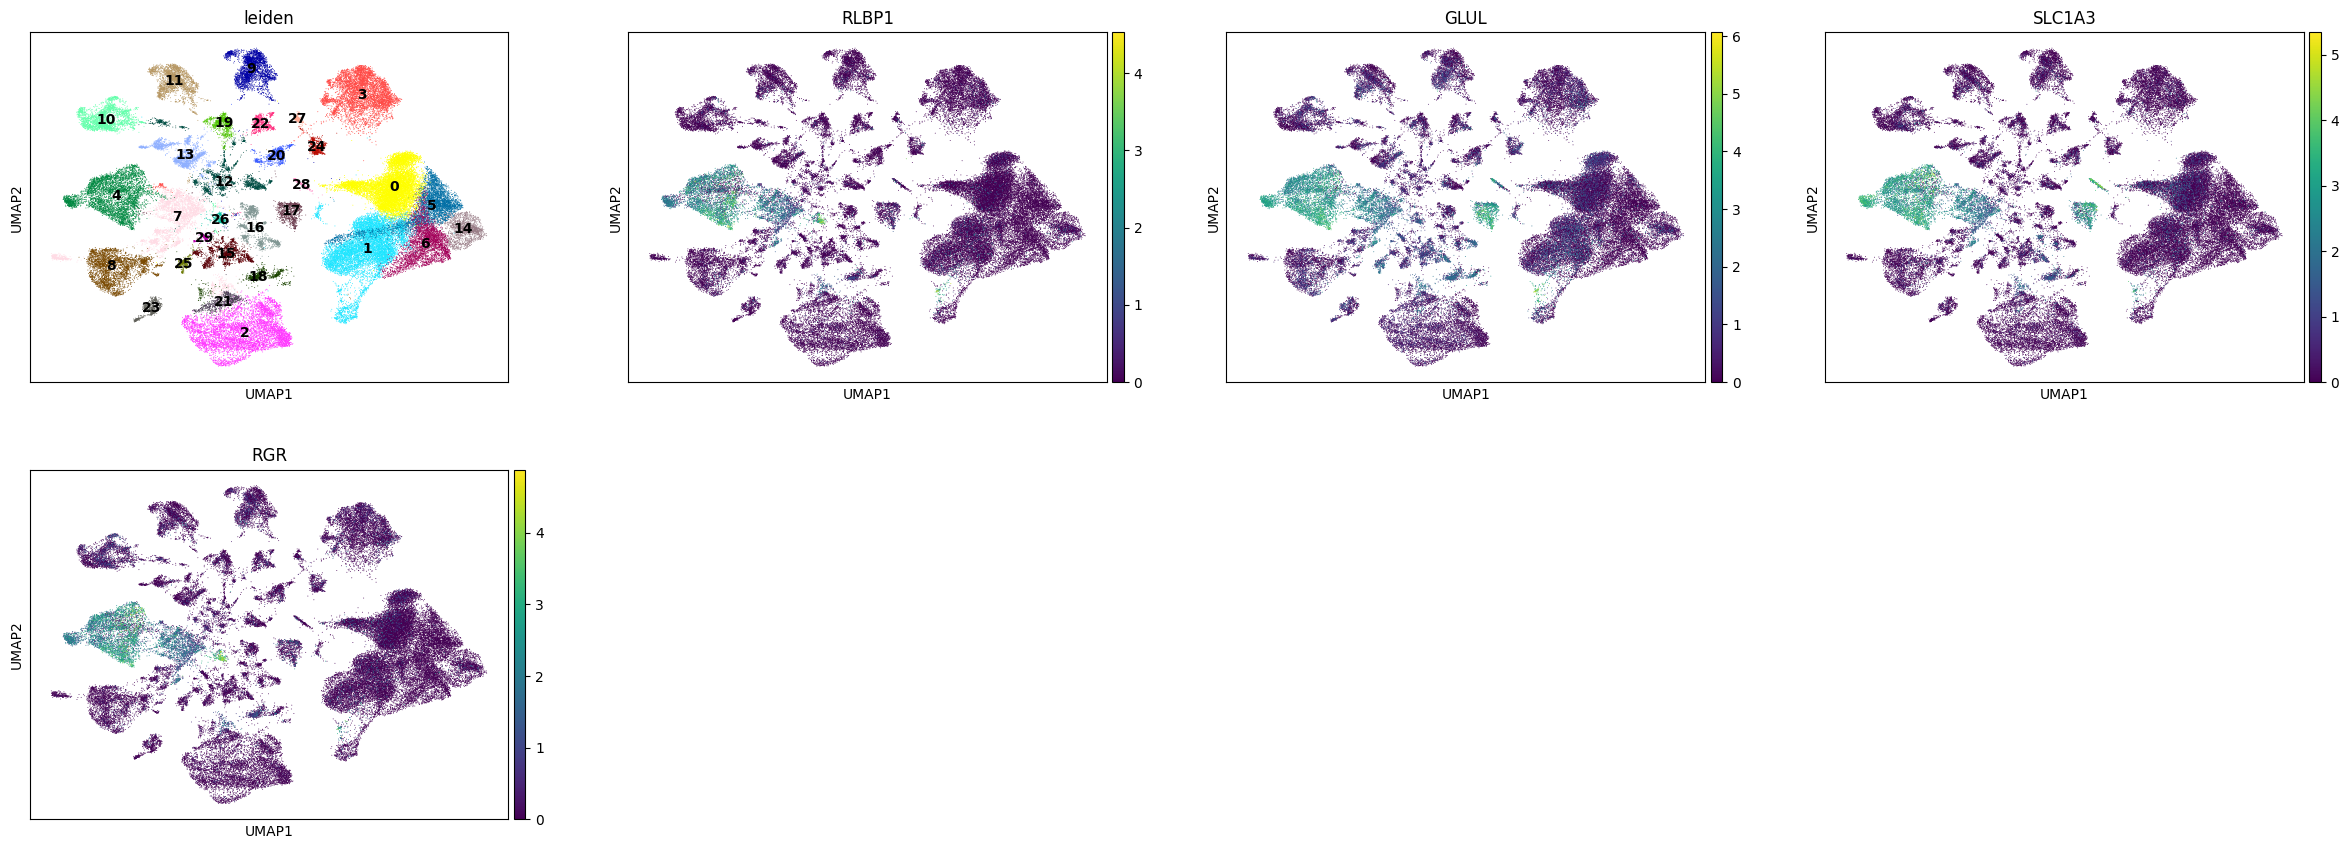

In [ ]:
sc.pl.umap(
    adata,
    color=["leiden", "RLBP1", "GLUL", "SLC1A3", "RGR"],
    legend_loc="on data"
)

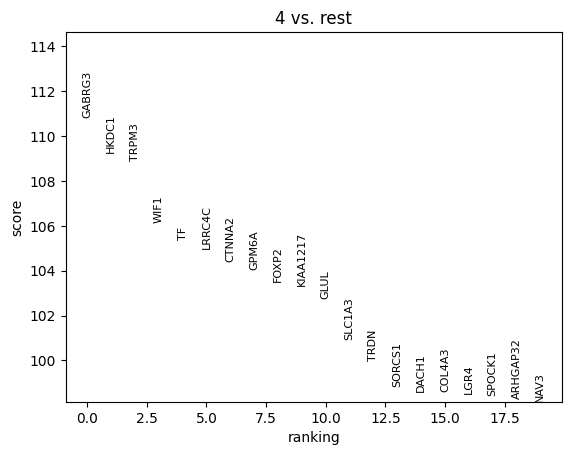

In [ ]:
sc.tl.rank_genes_groups(
    adata,
    groupby="leiden",
    groups=[best_cluster],
    reference="rest",
    method="wilcoxon"
)

sc.pl.rank_genes_groups(
    adata,
    groups=[best_cluster],
    n_genes=20
)

In [ ]:
muller_mask = adata.obs["leiden"] == best_cluster

muller_raw = sc.AnnData(
    X=X_raw[muller_mask.values].copy(),
    obs=adata.obs.loc[muller_mask].copy(),
    var=adata.var.copy()
)

print("Candidate Müller nuclei:", muller_raw.n_obs)
print(muller_raw.obs["condition_labels"].value_counts())

Candidate Müller nuclei: 4594
condition_labels
wAMD       1879
dAMD       1480
Healthy    1235
Name: count, dtype: int64


In [ ]:
from scipy.sparse import csr_matrix, vstack
import numpy as np
import pandas as pd

samples = muller_raw.obs["sample_labels"].unique()

pseudo_counts = []
pseudo_metadata = []

for sample in samples:

    mask = muller_raw.obs["sample_labels"] == sample

    # Sum raw counts from all Müller nuclei belonging to this retina
    summed = muller_raw.X[mask.values].sum(axis=0)

    # Force it into a clean 1 x genes row
    summed = np.asarray(summed).reshape(1, -1)

    pseudo_counts.append(csr_matrix(summed))

    pseudo_metadata.append({
        "sample": sample,
        "condition": muller_raw.obs.loc[
            mask, "condition_labels"
        ].iloc[0],
        "n_muller_nuclei": int(mask.sum())
    })

# Stack all 17 retinal samples
pseudo_X = vstack(pseudo_counts, format="csr")

pseudo_meta = pd.DataFrame(pseudo_metadata)

print("Pseudobulk matrix:", pseudo_X.shape)
print()
display(
    pseudo_meta.sort_values(["condition", "sample"])
)

Pseudobulk matrix: (17, 28261)



,sample,condition,n_muller_nuclei
12,A19-0065MR,Healthy,147
7,HC1941W,Healthy,182
8,HC1969,Healthy,513
9,HC2003,Healthy,77
10,HC2016,Healthy,309
11,HC2229,Healthy,7
13,A181974MR,dAMD,203
15,A192617MR,dAMD,502
16,AMD19-1891,dAMD,412
14,G1850,dAMD,363


In [ ]:
display(
    pseudo_meta[
        ["sample", "condition", "n_muller_nuclei"]
    ].sort_values("n_muller_nuclei")
)

,sample,condition,n_muller_nuclei
11,HC2229,Healthy,7
2,AMD1435,wAMD,43
9,HC2003,Healthy,77
12,A19-0065MR,Healthy,147
0,AMD0233,wAMD,158
7,HC1941W,Healthy,182
13,A181974MR,dAMD,203
1,AMD1098,wAMD,246
10,HC2016,Healthy,309
5,AMD201232,wAMD,327


In [ ]:
keep_samples = pseudo_meta["n_muller_nuclei"] >= 50

pseudo_X_filt = pseudo_X[keep_samples.values].copy()

pseudo_meta_filt = (
    pseudo_meta.loc[keep_samples]
    .copy()
    .reset_index(drop=True)
)

print("Samples retained:", len(pseudo_meta_filt))
print()
print(pseudo_meta_filt["condition"].value_counts())

display(pseudo_meta_filt)

Samples retained: 15

condition
wAMD       6
Healthy    5
dAMD       4
Name: count, dtype: int64


,sample,condition,n_muller_nuclei
0,AMD0233,wAMD,158
1,AMD1098,wAMD,246
2,AMD1547,wAMD,429
3,AMD192161MR,wAMD,334
4,AMD201232,wAMD,327
5,AMD201257,wAMD,342
6,HC1941W,Healthy,182
7,HC1969,Healthy,513
8,HC2003,Healthy,77
9,HC2016,Healthy,309


In [ ]:
counts_df = pd.DataFrame(
    pseudo_X_filt.toarray().astype(int),
    index=pseudo_meta_filt["sample"],
    columns=muller_raw.var_names
)

de_metadata = (
    pseudo_meta_filt
    .set_index("sample")[["condition"]]
)

# remove very sparse genes
gene_keep = (counts_df >= 10).sum(axis=0) >= 3
counts_filtered = counts_df.loc[:, gene_keep]

print("Final count matrix:", counts_filtered.shape)
display(de_metadata)

Final count matrix: (15, 12053)


,condition
sample,
AMD0233,wAMD
AMD1098,wAMD
AMD1547,wAMD
AMD192161MR,wAMD
AMD201232,wAMD
AMD201257,wAMD
HC1941W,Healthy
HC1969,Healthy
HC2003,Healthy


In [ ]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

dds = DeseqDataSet(
    counts=counts_filtered,
    metadata=de_metadata,
    design="~condition",
    refit_cooks=True
)

dds.deseq2()

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 13.06 seconds.

Fitting dispersion trend curve...
... done in 0.25 seconds.

Fitting MAP dispersions...
... done in 15.06 seconds.

Fitting LFCs...
... done in 8.02 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.



In [ ]:
stats_dry = DeseqStats(
    dds,
    contrast=["condition", "dAMD", "Healthy"]
)

stats_dry.summary()

dry_results = stats_dry.results_df.sort_values("padj")

display(
    dry_results[
        ["baseMean", "log2FoldChange", "pvalue", "padj"]
    ].head(20)
)

Running Wald tests...


Log2 fold change & Wald test p-value: condition dAMD vs Healthy
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A2M          8.636115        0.218808  0.623667  0.350841  0.725708  0.996253
A2ML1        8.756887        0.138987  0.757694  0.183435  0.854457  0.997758
A2ML1-AS1   10.620932        0.139530  0.838243  0.166455  0.867799  0.997758
AAAS         9.166191       -0.031985  0.556313 -0.057495  0.954151  0.997758
AACS        19.116180        0.392604  0.389990  1.006705  0.314077  0.987509
...               ...             ...       ...       ...       ...       ...
ZW10        13.614269       -0.204264  0.378218 -0.540068  0.589150  0.996253
ZXDC        96.106828        0.058693  0.227994  0.257431  0.796846  0.996741
ZYG11B      57.519334       -0.278176  0.253289 -1.098255  0.272093  0.987240
ZYX          7.020847       -0.185014  0.490698 -0.377042  0.706142  0.996253
ZZEF1      125.290407       -0.101346  0.313207 -0.323574  0.746260  0.996253


... done in 4.95 seconds.



,baseMean,log2FoldChange,pvalue,padj
FHIT,644.476227,-0.813473,0.000018,0.047787
ALDH1A2,737.274642,-0.857990,0.000006,0.047787
PRKCH,172.917261,-1.147165,0.000012,0.047787
LINGO2,168.087542,-1.514032,0.000015,0.047787
FBN2,232.026077,-2.168630,0.000020,0.047787
CEP128,159.274166,-1.420576,0.000046,0.092673
PDE3A,182.380633,-2.078695,0.000107,0.184378
GPR158,805.417139,-0.902991,0.000159,0.212588
HSPA1A,209.283112,6.325697,0.000149,0.212588
AC079447.1,87.305843,-1.023621,0.000212,0.231601


In [ ]:
stats_wet = DeseqStats(
    dds,
    contrast=["condition", "wAMD", "Healthy"]
)

stats_wet.summary()

wet_results = stats_wet.results_df.sort_values("padj")

display(
    wet_results[
        ["baseMean", "log2FoldChange", "pvalue", "padj"]
    ].head(20)
)

Running Wald tests...


Log2 fold change & Wald test p-value: condition wAMD vs Healthy
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A2M          8.636115        0.786030  0.567076  1.386111  0.165713  0.870020
A2ML1        8.756887        0.945615  0.684370  1.381731  0.167054  0.870020
A2ML1-AS1   10.620932        0.156254  0.767085  0.203698  0.838589  0.987082
AAAS         9.166191        0.435623  0.505691  0.861439  0.388996  0.922152
AACS        19.116180        0.340957  0.363273  0.938572  0.347951  0.913161
...               ...             ...       ...       ...       ...       ...
ZW10        13.614269        0.243398  0.342792  0.710046  0.477676  0.939568
ZXDC        96.106828        0.131582  0.209009  0.629554  0.528987  0.943638
ZYG11B      57.519334       -0.378076  0.233797 -1.617110  0.105855  0.867364
ZYX          7.020847       -0.426277  0.464941 -0.916841  0.359226  0.919912
ZZEF1      125.290407       -0.276017  0.285384 -0.967179  0.333454  0.910141


... done in 4.66 seconds.



,baseMean,log2FoldChange,pvalue,padj
ARHGAP33,12.699903,1.514949,0.000561,0.745722
HSPA1A,209.283112,5.174269,0.000633,0.745722
AC004231.1,12.717936,2.290901,0.000076,0.745722
RGS11,6.001392,3.586573,0.000309,0.745722
SLC22A17,24.766520,1.995416,0.000803,0.745722
ZNF213,15.623752,1.730477,0.000547,0.745722
KMT2E-AS1,6.824066,3.006827,0.000328,0.745722
SMIM37,4.594197,4.389309,0.000655,0.745722
UTY,73.983390,-9.070979,0.000854,0.745722
CCDC137,5.694296,2.109744,0.000726,0.745722


In [ ]:
# Add total counts and number of detected genes for each pseudobulk sample

pseudo_meta["library_size"] = np.asarray(
    pseudo_X.sum(axis=1)
).flatten()

pseudo_meta["detected_genes"] = np.asarray(
    (pseudo_X > 0).sum(axis=1)
).flatten()

display(
    pseudo_meta[
        [
            "sample",
            "condition",
            "n_muller_nuclei",
            "library_size",
            "detected_genes"
        ]
    ].sort_values("n_muller_nuclei")
)

,sample,condition,n_muller_nuclei,library_size,detected_genes
11,HC2229,Healthy,7,9167,4026
2,AMD1435,wAMD,43,78659,10417
9,HC2003,Healthy,77,224159,13512
12,A19-0065MR,Healthy,147,465465,15222
0,AMD0233,wAMD,158,829978,16666
7,HC1941W,Healthy,182,897776,16027
13,A181974MR,dAMD,203,1058164,17821
1,AMD1098,wAMD,246,592649,16629
10,HC2016,Healthy,309,875510,16359
5,AMD201232,wAMD,327,990952,17543


In [ ]:
keep_samples = pseudo_meta["n_muller_nuclei"] >= 50

pseudo_X_filt = pseudo_X[keep_samples.values].copy()
pseudo_meta_filt = pseudo_meta.loc[keep_samples].copy().reset_index(drop=True)

print("Samples retained:", len(pseudo_meta_filt))
print(pseudo_meta_filt["condition"].value_counts())

display(pseudo_meta_filt)

Samples retained: 15
condition
wAMD       6
Healthy    5
dAMD       4
Name: count, dtype: int64


,sample,condition,n_muller_nuclei,library_size,detected_genes
0,AMD0233,wAMD,158,829978,16666
1,AMD1098,wAMD,246,592649,16629
2,AMD1547,wAMD,429,1889346,19628
3,AMD192161MR,wAMD,334,1908893,19507
4,AMD201232,wAMD,327,990952,17543
5,AMD201257,wAMD,342,1387309,19268
6,HC1941W,Healthy,182,897776,16027
7,HC1969,Healthy,513,4036982,19855
8,HC2003,Healthy,77,224159,13512
9,HC2016,Healthy,309,875510,16359


In [ ]:
counts_df = pd.DataFrame(
    pseudo_X_filt.toarray().astype(int),
    index=pseudo_meta_filt["sample"],
    columns=muller_raw.var_names
)

de_metadata = (
    pseudo_meta_filt
    .set_index("sample")[["condition"]]
)

print(counts_df.shape)
display(de_metadata)

(15, 28261)


,condition
sample,
AMD0233,wAMD
AMD1098,wAMD
AMD1547,wAMD
AMD192161MR,wAMD
AMD201232,wAMD
AMD201257,wAMD
HC1941W,Healthy
HC1969,Healthy
HC2003,Healthy


In [ ]:
gene_keep = (counts_df >= 10).sum(axis=0) >= 3

counts_filtered = counts_df.loc[:, gene_keep]

print("Genes before filtering:", counts_df.shape[1])
print("Genes retained:", counts_filtered.shape[1])

Genes before filtering: 28261
Genes retained: 12053


In [ ]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

dds = DeseqDataSet(
    counts=counts_filtered,
    metadata=de_metadata,
    design="~condition",
    refit_cooks=True
)

dds.deseq2()

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 13.24 seconds.

Fitting dispersion trend curve...
... done in 0.28 seconds.

Fitting MAP dispersions...
... done in 14.51 seconds.

Fitting LFCs...
... done in 9.82 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.



In [ ]:
stats_dry = DeseqStats(
    dds,
    contrast=["condition", "dAMD", "Healthy"]
)

stats_dry.summary()

dry_results = stats_dry.results_df.sort_values("padj")

display(
    dry_results[
        ["baseMean", "log2FoldChange", "pvalue", "padj"]
    ].head(20)
)

Running Wald tests...


Log2 fold change & Wald test p-value: condition dAMD vs Healthy
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A2M          8.636115        0.218808  0.623667  0.350841  0.725708  0.996253
A2ML1        8.756887        0.138987  0.757694  0.183435  0.854457  0.997758
A2ML1-AS1   10.620932        0.139530  0.838243  0.166455  0.867799  0.997758
AAAS         9.166191       -0.031985  0.556313 -0.057495  0.954151  0.997758
AACS        19.116180        0.392604  0.389990  1.006705  0.314077  0.987509
...               ...             ...       ...       ...       ...       ...
ZW10        13.614269       -0.204264  0.378218 -0.540068  0.589150  0.996253
ZXDC        96.106828        0.058693  0.227994  0.257431  0.796846  0.996741
ZYG11B      57.519334       -0.278176  0.253289 -1.098255  0.272093  0.987240
ZYX          7.020847       -0.185014  0.490698 -0.377042  0.706142  0.996253
ZZEF1      125.290407       -0.101346  0.313207 -0.323574  0.746260  0.996253


... done in 4.22 seconds.



,baseMean,log2FoldChange,pvalue,padj
FHIT,644.476227,-0.813473,0.000018,0.047787
ALDH1A2,737.274642,-0.857990,0.000006,0.047787
PRKCH,172.917261,-1.147165,0.000012,0.047787
LINGO2,168.087542,-1.514032,0.000015,0.047787
FBN2,232.026077,-2.168630,0.000020,0.047787
CEP128,159.274166,-1.420576,0.000046,0.092673
PDE3A,182.380633,-2.078695,0.000107,0.184378
GPR158,805.417139,-0.902991,0.000159,0.212588
HSPA1A,209.283112,6.325697,0.000149,0.212588
AC079447.1,87.305843,-1.023621,0.000212,0.231601


In [ ]:
keep_samples = pseudo_meta["n_muller_nuclei"] >= 50

pseudo_X_filt = pseudo_X[keep_samples.values].copy()

pseudo_meta_filt = (
    pseudo_meta.loc[keep_samples]
    .copy()
    .reset_index(drop=True)
)

print("Samples retained:", len(pseudo_meta_filt))
print()
print(pseudo_meta_filt["condition"].value_counts())

display(pseudo_meta_filt)

Samples retained: 15

condition
wAMD       6
Healthy    5
dAMD       4
Name: count, dtype: int64


,sample,condition,n_muller_nuclei,library_size,detected_genes
0,AMD0233,wAMD,158,829978,16666
1,AMD1098,wAMD,246,592649,16629
2,AMD1547,wAMD,429,1889346,19628
3,AMD192161MR,wAMD,334,1908893,19507
4,AMD201232,wAMD,327,990952,17543
5,AMD201257,wAMD,342,1387309,19268
6,HC1941W,Healthy,182,897776,16027
7,HC1969,Healthy,513,4036982,19855
8,HC2003,Healthy,77,224159,13512
9,HC2016,Healthy,309,875510,16359


In [ ]:
counts_df = pd.DataFrame(
    pseudo_X_filt.toarray().astype(int),
    index=pseudo_meta_filt["sample"],
    columns=muller_raw.var_names
)

de_metadata = (
    pseudo_meta_filt
    .set_index("sample")[["condition"]]
)

# remove very sparse genes
gene_keep = (counts_df >= 10).sum(axis=0) >= 3
counts_filtered = counts_df.loc[:, gene_keep]

print("Final count matrix:", counts_filtered.shape)
display(de_metadata)

Final count matrix: (15, 12053)


,condition
sample,
AMD0233,wAMD
AMD1098,wAMD
AMD1547,wAMD
AMD192161MR,wAMD
AMD201232,wAMD
AMD201257,wAMD
HC1941W,Healthy
HC1969,Healthy
HC2003,Healthy


In [ ]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

dds = DeseqDataSet(
    counts=counts_filtered,
    metadata=de_metadata,
    design="~condition",
    refit_cooks=True
)

dds.deseq2()

Fitting size factors...
... done in 0.01 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 16.23 seconds.

Fitting dispersion trend curve...
... done in 0.26 seconds.

Fitting MAP dispersions...
... done in 15.03 seconds.

Fitting LFCs...
... done in 8.87 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.



In [ ]:
stats_dry = DeseqStats(
    dds,
    contrast=["condition", "dAMD", "Healthy"]
)

stats_dry.summary()

dry_results = stats_dry.results_df.sort_values("padj")

display(
    dry_results[
        ["baseMean", "log2FoldChange", "pvalue", "padj"]
    ].head(20)
)

Running Wald tests...
... done in 6.94 seconds.



Log2 fold change & Wald test p-value: condition dAMD vs Healthy
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A2M          8.636115        0.218808  0.623667  0.350841  0.725708  0.996253
A2ML1        8.756887        0.138987  0.757694  0.183435  0.854457  0.997758
A2ML1-AS1   10.620932        0.139530  0.838243  0.166455  0.867799  0.997758
AAAS         9.166191       -0.031985  0.556313 -0.057495  0.954151  0.997758
AACS        19.116180        0.392604  0.389990  1.006705  0.314077  0.987509
...               ...             ...       ...       ...       ...       ...
ZW10        13.614269       -0.204264  0.378218 -0.540068  0.589150  0.996253
ZXDC        96.106828        0.058693  0.227994  0.257431  0.796846  0.996741
ZYG11B      57.519334       -0.278176  0.253289 -1.098255  0.272093  0.987240
ZYX          7.020847       -0.185014  0.490698 -0.377042  0.706142  0.996253
ZZEF1      125.290407       -0.101346  0.313207 -0.323574  0.746260  0.996253


,baseMean,log2FoldChange,pvalue,padj
FHIT,644.476227,-0.813473,0.000018,0.047787
ALDH1A2,737.274642,-0.857990,0.000006,0.047787
PRKCH,172.917261,-1.147165,0.000012,0.047787
LINGO2,168.087542,-1.514032,0.000015,0.047787
FBN2,232.026077,-2.168630,0.000020,0.047787
CEP128,159.274166,-1.420576,0.000046,0.092673
PDE3A,182.380633,-2.078695,0.000107,0.184378
GPR158,805.417139,-0.902991,0.000159,0.212588
HSPA1A,209.283112,6.325697,0.000149,0.212588
AC079447.1,87.305843,-1.023621,0.000212,0.231601


In [ ]:
stats_wet = DeseqStats(
    dds,
    contrast=["condition", "wAMD", "Healthy"]
)

stats_wet.summary()

wet_results = stats_wet.results_df.sort_values("padj")

display(
    wet_results[
        ["baseMean", "log2FoldChange", "pvalue", "padj"]
    ].head(20)
)

Running Wald tests...


Log2 fold change & Wald test p-value: condition wAMD vs Healthy
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A2M          8.636115        0.786030  0.567076  1.386111  0.165713  0.870020
A2ML1        8.756887        0.945615  0.684370  1.381731  0.167054  0.870020
A2ML1-AS1   10.620932        0.156254  0.767085  0.203698  0.838589  0.987082
AAAS         9.166191        0.435623  0.505691  0.861439  0.388996  0.922152
AACS        19.116180        0.340957  0.363273  0.938572  0.347951  0.913161
...               ...             ...       ...       ...       ...       ...
ZW10        13.614269        0.243398  0.342792  0.710046  0.477676  0.939568
ZXDC        96.106828        0.131582  0.209009  0.629554  0.528987  0.943638
ZYG11B      57.519334       -0.378076  0.233797 -1.617110  0.105855  0.867364
ZYX          7.020847       -0.426277  0.464941 -0.916841  0.359226  0.919912
ZZEF1      125.290407       -0.276017  0.285384 -0.967179  0.333454  0.910141


... done in 4.20 seconds.



,baseMean,log2FoldChange,pvalue,padj
ARHGAP33,12.699903,1.514949,0.000561,0.745722
HSPA1A,209.283112,5.174269,0.000633,0.745722
AC004231.1,12.717936,2.290901,0.000076,0.745722
RGS11,6.001392,3.586573,0.000309,0.745722
SLC22A17,24.766520,1.995416,0.000803,0.745722
ZNF213,15.623752,1.730477,0.000547,0.745722
KMT2E-AS1,6.824066,3.006827,0.000328,0.745722
SMIM37,4.594197,4.389309,0.000655,0.745722
UTY,73.983390,-9.070979,0.000854,0.745722
CCDC137,5.694296,2.109744,0.000726,0.745722


In [ ]:
def summarize_de(results, name):
    print(name)
    print("Genes tested:", len(results))
    print("padj < 0.05:", (results["padj"] < 0.05).sum())
    print("padj < 0.10:", (results["padj"] < 0.10).sum())
    print()

summarize_de(dry_results, "Dry AMD vs Healthy")
summarize_de(wet_results, "Wet AMD vs Healthy")

Dry AMD vs Healthy
Genes tested: 12053
padj < 0.05: 5
padj < 0.10: 6

Wet AMD vs Healthy
Genes tested: 12053
padj < 0.05: 0
padj < 0.10: 0



In [ ]:
import gseapy as gp

In [ ]:
dry_rank = (
    dry_results[["stat"]]
    .dropna()
    .sort_values("stat", ascending=False)
)

wet_rank = (
    wet_results[["stat"]]
    .dropna()
    .sort_values("stat", ascending=False)
)

print("Dry genes:", len(dry_rank))
print("Wet genes:", len(wet_rank))

Dry genes: 12053
Wet genes: 12053


In [ ]:
dry_gsea = gp.prerank(
    rnk=dry_rank,
    gene_sets="MSigDB_Hallmark_2020",
    organism="Human",
    permutation_num=1000,
    seed=42,
    verbose=False
)

dry_pathways = dry_gsea.res2d.sort_values("FDR q-val")

display(
    dry_pathways[
        ["Term", "NES", "NOM p-val", "FDR q-val"]
    ].head(15)
)

,Term,NES,NOM p-val,FDR q-val
0,Oxidative Phosphorylation,2.225153,0.000000,0.000000
1,UV Response Up,2.127376,0.000000,0.000000
2,Myc Targets V1,2.094133,0.000000,0.000000
3,Reactive Oxygen Species Pathway,2.042112,0.000000,0.000000
4,p53 Pathway,2.015708,0.000000,0.000254
5,Fatty Acid Metabolism,1.900873,0.000000,0.001480
6,Adipogenesis,1.755501,0.000000,0.007432
7,mTORC1 Signaling,1.708779,0.000000,0.010151
9,Xenobiotic Metabolism,1.627189,0.001597,0.020303
10,Myogenesis,1.569912,0.006135,0.030708


In [ ]:
wet_gsea = gp.prerank(
    rnk=wet_rank,
    gene_sets="MSigDB_Hallmark_2020",
    organism="Human",
    permutation_num=1000,
    seed=42,
    verbose=False
)

wet_pathways = wet_gsea.res2d.sort_values("FDR q-val")

display(
    wet_pathways[
        ["Term", "NES", "NOM p-val", "FDR q-val"]
    ].head(15)
)

,Term,NES,NOM p-val,FDR q-val
0,p53 Pathway,1.845772,0.000000,0.013629
3,Reactive Oxygen Species Pathway,1.672747,0.009852,0.021754
5,Myc Targets V1,1.631305,0.000000,0.028726
2,Oxidative Phosphorylation,1.673772,0.001441,0.029005
6,Epithelial Mesenchymal Transition,1.616821,0.001475,0.029005
8,Coagulation,1.584066,0.014331,0.033398
1,UV Response Up,1.694184,0.001527,0.035121
9,Myogenesis,1.533910,0.004425,0.046129
4,UV Response Dn,-1.658176,0.000000,0.050999
7,Protein Secretion,-1.587265,0.005764,0.057374


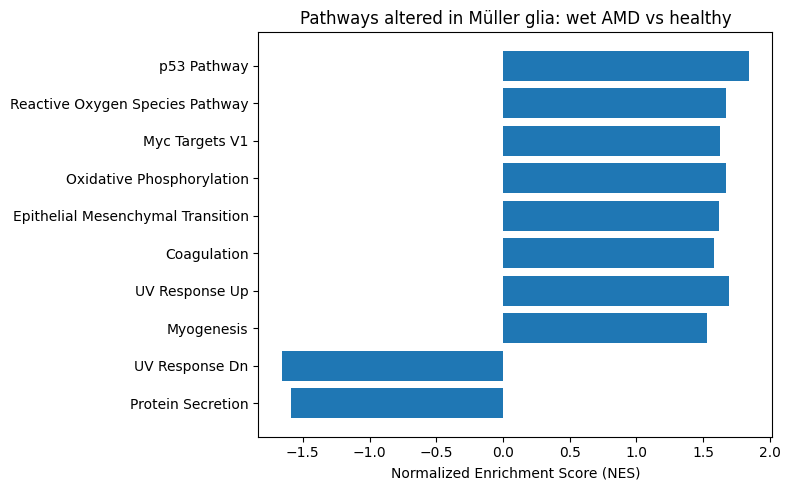

In [ ]:
top = wet_pathways.head(10).copy()

plt.figure(figsize=(8,5))
plt.barh(
    top["Term"][::-1],
    top["NES"][::-1]
)

plt.xlabel("Normalized Enrichment Score (NES)")
plt.title("Pathways altered in Müller glia: wet AMD vs healthy")
plt.tight_layout()
plt.show()

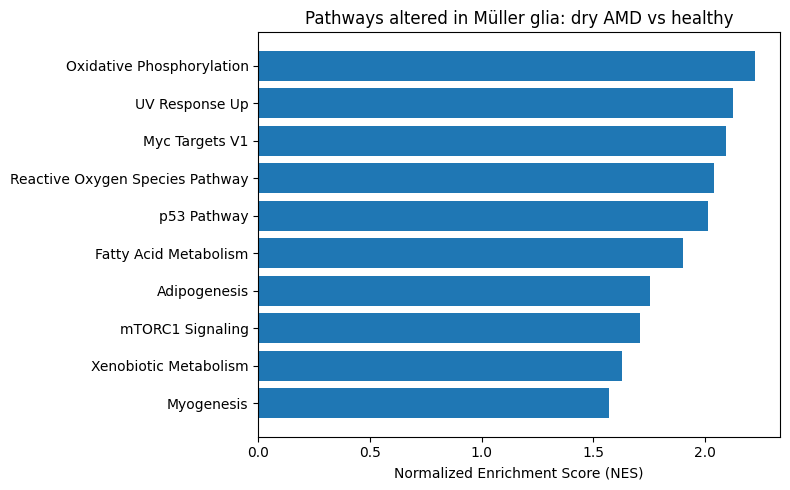

In [ ]:
top = dry_pathways.head(10).copy()

plt.figure(figsize=(8,5))
plt.barh(
    top["Term"][::-1],
    top["NES"][::-1]
)

plt.xlabel("Normalized Enrichment Score (NES)")
plt.title("Pathways altered in Müller glia: dry AMD vs healthy")
plt.tight_layout()
plt.show()

In [ ]:
display(
    dry_pathways[
        ["Term", "NES", "NOM p-val", "FDR q-val"]
    ].head(15)
)

display(
    wet_pathways[
        ["Term", "NES", "NOM p-val", "FDR q-val"]
    ].head(15)
)

,Term,NES,NOM p-val,FDR q-val
0,Oxidative Phosphorylation,2.225153,0.000000,0.000000
1,UV Response Up,2.127376,0.000000,0.000000
2,Myc Targets V1,2.094133,0.000000,0.000000
3,Reactive Oxygen Species Pathway,2.042112,0.000000,0.000000
4,p53 Pathway,2.015708,0.000000,0.000254
5,Fatty Acid Metabolism,1.900873,0.000000,0.001480
6,Adipogenesis,1.755501,0.000000,0.007432
7,mTORC1 Signaling,1.708779,0.000000,0.010151
9,Xenobiotic Metabolism,1.627189,0.001597,0.020303
10,Myogenesis,1.569912,0.006135,0.030708


,Term,NES,NOM p-val,FDR q-val
0,p53 Pathway,1.845772,0.000000,0.013629
3,Reactive Oxygen Species Pathway,1.672747,0.009852,0.021754
5,Myc Targets V1,1.631305,0.000000,0.028726
2,Oxidative Phosphorylation,1.673772,0.001441,0.029005
6,Epithelial Mesenchymal Transition,1.616821,0.001475,0.029005
8,Coagulation,1.584066,0.014331,0.033398
1,UV Response Up,1.694184,0.001527,0.035121
9,Myogenesis,1.533910,0.004425,0.046129
4,UV Response Dn,-1.658176,0.000000,0.050999
7,Protein Secretion,-1.587265,0.005764,0.057374


In [ ]:
for name, df in [("Dry AMD", dry_pathways), ("Wet AMD", wet_pathways)]:
    print(name)
    print("FDR < 0.05:", (df["FDR q-val"] < 0.05).sum())
    print("FDR < 0.10:", (df["FDR q-val"] < 0.10).sum())
    print("FDR < 0.25:", (df["FDR q-val"] < 0.25).sum())
    print()

Dry AMD
FDR < 0.05: 13
FDR < 0.10: 17
FDR < 0.25: 19

Wet AMD
FDR < 0.05: 8
FDR < 0.10: 12
FDR < 0.25: 20



In [ ]:
sig_dry = dry_pathways[
    dry_pathways["FDR q-val"] < 0.05
][["Term", "NES", "NOM p-val", "FDR q-val", "Lead_genes"]]

sig_wet = wet_pathways[
    wet_pathways["FDR q-val"] < 0.05
][["Term", "NES", "NOM p-val", "FDR q-val", "Lead_genes"]]

print("DRY AMD")
display(sig_dry)

print("\nWET AMD")
display(sig_wet)

DRY AMD


,Term,NES,NOM p-val,FDR q-val,Lead_genes
0,Oxidative Phosphorylation,2.225153,0.000000,0.000000,ATP5F1B;UQCRFS1;ATP5F1A;ATP6V0B;ECI1;VDAC3;VDA...
1,UV Response Up,2.127376,0.000000,0.000000,FKBP4;TUBA4A;CLTB;DNAJB1;DNAJA1;CDKN1C;TYRO3;C...
2,Myc Targets V1,2.094133,0.000000,0.000000,HSP90AB1;TYMS;CCT3;CCT4;RPS3;NOP56;VDAC3;CBX3;...
3,Reactive Oxygen Species Pathway,2.042112,0.000000,0.000000,PRDX1;GLRX;G6PD;SOD1;NDUFA6;ERCC2;FTL;NDUFB4;T...
4,p53 Pathway,2.015708,0.000000,0.000254,DDIT3;PMM1;CTSF;LIF;CYFIP2;RNF19B;MXD4;DCXR;LD...
5,Fatty Acid Metabolism,1.900873,0.000000,0.001480,HSP90AA1;HSPH1;ECI1;TP53INP2;PCBD1;ENO2;ACAA1;...
6,Adipogenesis,1.755501,0.000000,0.007432,SOD1;UBC;PTCD3;MDH2;CHCHD10;SLC19A1;MRPL15;HSP...
7,mTORC1 Signaling,1.708779,0.000000,0.010151,DDIT3;TUBA4A;PRDX1;GLRX;CACYBP;HSPA5;G6PD;HSPA...
9,Xenobiotic Metabolism,1.627189,0.001597,0.020303,HSD17B2;BCAR1;PMM1;CYFIP2;DCXR;PTGDS;BLVRB;PTG...
10,Myogenesis,1.569912,0.006135,0.030708,PTP4A3;BIN1;FXYD1;ATP2A1;PDLIM7;CRYAB;GABARAPL...



WET AMD


,Term,NES,NOM p-val,FDR q-val,Lead_genes
0,p53 Pathway,1.845772,0.000000,0.013629,RACK1;CTSF;ZMAT3;TSPYL2;S100A10;CYFIP2;BAX;EPH...
3,Reactive Oxygen Species Pathway,1.672747,0.009852,0.021754,G6PD;ERCC2;GLRX;FTL;NDUFA6;TXNRD1;STK25;PRDX1;...
5,Myc Targets V1,1.631305,0.000000,0.028726,RACK1;MCM7;RFC4;NOP56;RPLP0;EIF4H;TYMS;RPL14;H...
2,Oxidative Phosphorylation,1.673772,0.001441,0.029005,IDH2;ACAA1;TIMM13;NDUFA6;ATP5F1B;SLC25A5;HTRA2...
6,Epithelial Mesenchymal Transition,1.616821,0.001475,0.029005,MEST;EMP3;MCM7;PPIB;PLOD1;FLNA;LRP1;TPM2;ENO2;...
8,Coagulation,1.584066,0.014331,0.033398,LRP1;C1R;SERPING1;S100A1;FN1;S100A13;TIMP1;MMP...
1,UV Response Up,1.694184,0.001527,0.035121,TUBA4A;RFC4;CLTB;UROD;ACAA1;EPHX1;ENO2;DNAJB1;...
9,Myogenesis,1.533910,0.004425,0.046129,FABP3;FXYD1;MYL6B;BIN1;GAA;TPM2;PTP4A3;ATP6AP1...


In [ ]:
shared = sig_dry.merge(
    sig_wet,
    on="Term",
    suffixes=("_dry", "_wet")
)

shared = shared[
    [
        "Term",
        "NES_dry",
        "FDR q-val_dry",
        "NES_wet",
        "FDR q-val_wet"
    ]
]

display(shared.sort_values("FDR q-val_dry"))

,Term,NES_dry,FDR q-val_dry,NES_wet,FDR q-val_wet
0,Oxidative Phosphorylation,2.225153,0.000000,1.673772,0.029005
1,UV Response Up,2.127376,0.000000,1.694184,0.035121
2,Myc Targets V1,2.094133,0.000000,1.631305,0.028726
3,Reactive Oxygen Species Pathway,2.042112,0.000000,1.672747,0.021754
4,p53 Pathway,2.015708,0.000254,1.845772,0.013629
5,Myogenesis,1.569912,0.030708,1.533910,0.046129


In [ ]:
pathways_of_interest = [
    "Oxidative Phosphorylation",
    "Reactive Oxygen Species Pathway",
    "p53 Pathway"
]

for pathway in pathways_of_interest:
    print("\n==========", pathway, "==========")

    print("\nDry AMD:")
    display(
        dry_pathways.loc[
            dry_pathways["Term"] == pathway,
            ["NES", "FDR q-val", "Lead_genes"]
        ]
    )

    print("\nWet AMD:")
    display(
        wet_pathways.loc[
            wet_pathways["Term"] == pathway,
            ["NES", "FDR q-val", "Lead_genes"]
        ]
    )


========== Oxidative Phosphorylation ==========

Dry AMD:


,NES,FDR q-val,Lead_genes
0,2.225153,0.0,ATP5F1B;UQCRFS1;ATP5F1A;ATP6V0B;ECI1;VDAC3;VDA...



Wet AMD:


,NES,FDR q-val,Lead_genes
2,1.673772,0.029005,IDH2;ACAA1;TIMM13;NDUFA6;ATP5F1B;SLC25A5;HTRA2...



========== Reactive Oxygen Species Pathway ==========

Dry AMD:


...

,NES,FDR q-val,Lead_genes
3,1.672747,0.021754,G6PD;ERCC2;GLRX;FTL;NDUFA6;TXNRD1;STK25;PRDX1;...



========== p53 Pathway ==========

Dry AMD:


,NES,FDR q-val,Lead_genes
4,2.015708,0.000254,DDIT3;PMM1;CTSF;LIF;CYFIP2;RNF19B;MXD4;DCXR;LD...



Wet AMD:


,NES,FDR q-val,Lead_genes
0,1.845772,0.013629,RACK1;CTSF;ZMAT3;TSPYL2;S100A10;CYFIP2;BAX;EPH...


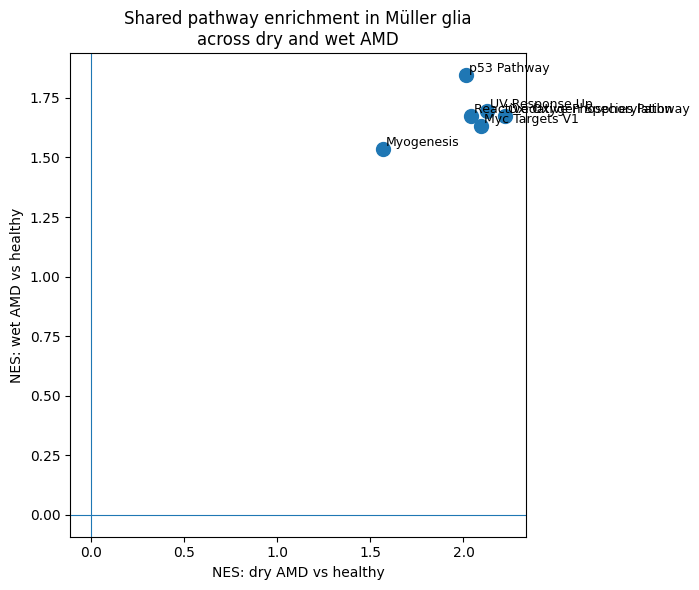

In [ ]:
shared_plot = shared.copy()

plt.figure(figsize=(7,6))

plt.scatter(
    shared_plot["NES_dry"],
    shared_plot["NES_wet"],
    s=100
)

for _, row in shared_plot.iterrows():
    plt.text(
        row["NES_dry"] + 0.015,
        row["NES_wet"] + 0.015,
        row["Term"],
        fontsize=9
    )

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.xlabel("NES: dry AMD vs healthy")
plt.ylabel("NES: wet AMD vs healthy")

plt.title(
    "Shared pathway enrichment in Müller glia\n"
    "across dry and wet AMD"
)

plt.tight_layout()
plt.savefig(
    "shared_AMD_Muller_pathways.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
dry_results.to_csv("dry_AMD_vs_healthy_DE.csv")
wet_results.to_csv("wet_AMD_vs_healthy_DE.csv")

dry_pathways.to_csv("dry_AMD_GSEA.csv", index=False)
wet_pathways.to_csv("wet_AMD_GSEA.csv", index=False)

shared.to_csv("shared_significant_pathways.csv", index=False)

pseudo_meta_filt.to_csv(
    "Muller_pseudobulk_sample_metadata.csv",
    index=False
)

print("Results saved.")

Results saved.


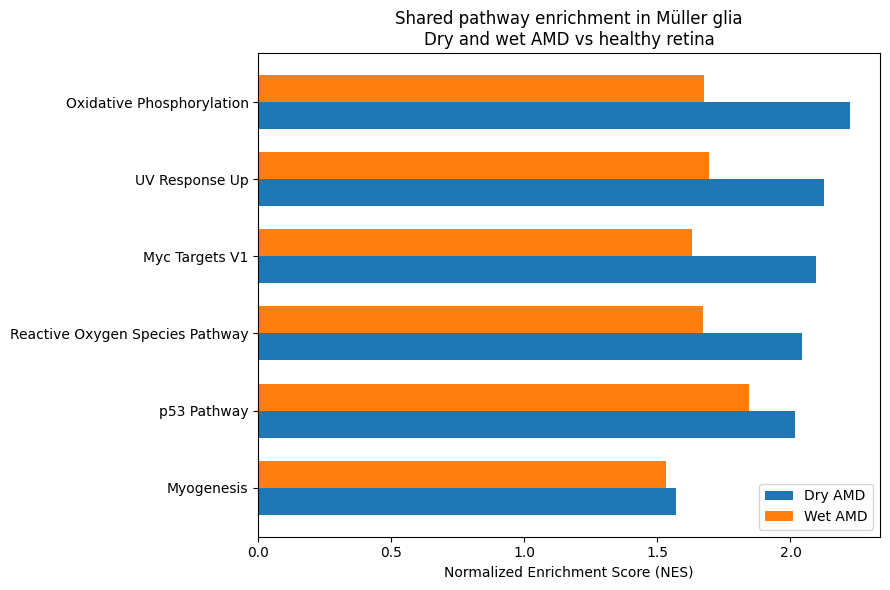

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plot_df = shared.sort_values("NES_dry", ascending=True).copy()

y = np.arange(len(plot_df))
height = 0.35

plt.figure(figsize=(9, 6))

plt.barh(
    y - height/2,
    plot_df["NES_dry"],
    height,
    label="Dry AMD"
)

plt.barh(
    y + height/2,
    plot_df["NES_wet"],
    height,
    label="Wet AMD"
)

plt.yticks(y, plot_df["Term"])

plt.xlabel("Normalized Enrichment Score (NES)")
plt.title(
    "Shared pathway enrichment in Müller glia\n"
    "Dry and wet AMD vs healthy retina"
)

plt.legend()
plt.tight_layout()

plt.savefig(
    "shared_AMD_Muller_pathways_final.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [1]:
for name in [
    "dry_results",
    "wet_results",
    "dry_pathways",
    "wet_pathways",
    "shared",
    "pseudo_meta_filt"
]:
    print(name, name in globals())

dry_results False
wet_results False
dry_pathways False
wet_pathways False
shared False
pseudo_meta_filt False
